# Clustering — Credit Card Fraud Detection

## Overview
In this notebook, we apply **K-Means**, **Hierarchical Clustering**, and **DBSCAN** to explore patterns in the credit card transaction dataset without using labels.

We cover:
- K-Means clustering from scratch
- Hierarchical clustering with dendrogram visualization
- DBSCAN for density-based clustering
- Evaluation using silhouette score

## What is Clustering?
Clustering is an unsupervised learning technique that groups data points based on similarity. Unlike classification, there are no predefined labels — the algorithm discovers structure in the data.

**K-Means** minimizes within-cluster variance:
$$J = \sum_{k=1}^{K} \sum_{x \in C_k} \|x - \mu_k\|^2$$

**DBSCAN** groups points that are closely packed together, marking outliers as noise.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
from scipy.cluster.hierarchy import dendrogram, linkage

pd.set_option('display.max_columns', 50)
plt.style.use('seaborn-v0_8')
%matplotlib inline

## 1. Load & Preprocess Data

In [2]:
df = pd.read_csv('/Users/apple/Desktop/CMOR438/CMOR438-Spring2026/data/credit_fraud/creditcard.csv')

# Use a balanced sample for clustering
fraud = df[df['Class'] == 1]
normal = df[df['Class'] == 0].sample(len(fraud), random_state=42)
df_balanced = pd.concat([fraud, normal]).sample(frac=1, random_state=42)

# Drop target column — unsupervised
X = df_balanced.drop('Class', axis=1).values
y_true = df_balanced['Class'].values

# Scale
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Reduce to 2D with PCA for visualization
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

print("Dataset shape:", X_scaled.shape)

Dataset shape: (984, 30)


## 2. K-Means from Scratch

In [3]:
class KMeansScratch:
    def __init__(self, k=2, max_iters=100, random_state=42):
        self.k = k
        self.max_iters = max_iters
        self.random_state = random_state

    def fit(self, X):
        np.random.seed(self.random_state)
        idx = np.random.choice(len(X), self.k, replace=False)
        self.centroids = X[idx]

        for _ in range(self.max_iters):
            labels = self._assign(X)
            new_centroids = np.array([X[labels == k].mean(axis=0) for k in range(self.k)])
            if np.allclose(self.centroids, new_centroids):
                break
            self.centroids = new_centroids
        self.labels_ = labels

    def _assign(self, X):
        distances = np.sqrt(((X[:, np.newaxis] - self.centroids) ** 2).sum(axis=2))
        return np.argmin(distances, axis=1)

    def predict(self, X):
        return self._assign(X)

# Train
kmeans_scratch = KMeansScratch(k=2)
kmeans_scratch.fit(X_pca)

sil = silhouette_score(X_pca, kmeans_scratch.labels_)
print(f"K-Means Scratch — Silhouette Score: {sil:.4f}")

K-Means Scratch — Silhouette Score: 0.7109


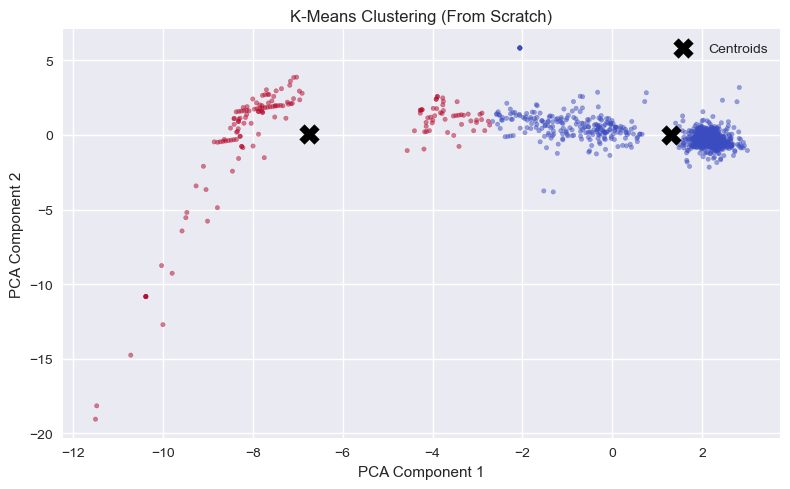

In [4]:
# Plot K-Means result
plt.figure(figsize=(8, 5))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=kmeans_scratch.labels_, cmap='coolwarm', alpha=0.5, s=10)
plt.scatter(kmeans_scratch.centroids[:, 0], kmeans_scratch.centroids[:, 1],
            c='black', marker='X', s=200, label='Centroids')
plt.title('K-Means Clustering (From Scratch)')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.legend()
plt.tight_layout()
plt.show()

## 3. Choosing Optimal K (Elbow Method)

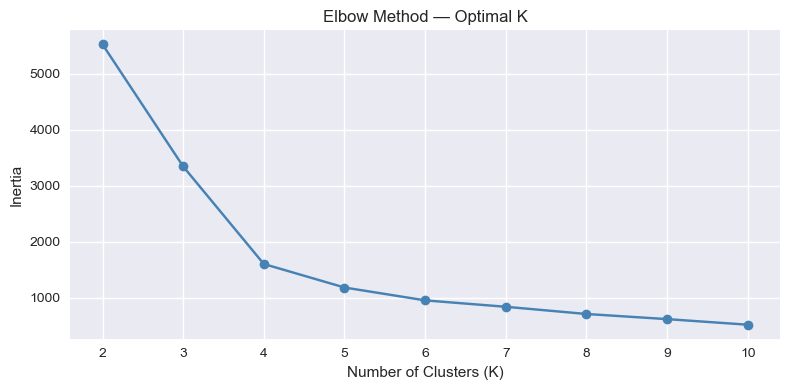

In [5]:
inertias = []
k_values = range(2, 11)

for k in k_values:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_pca)
    inertias.append(km.inertia_)

plt.figure(figsize=(8, 4))
plt.plot(k_values, inertias, marker='o', color='steelblue')
plt.title('Elbow Method — Optimal K')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.tight_layout()
plt.show()

## 4. Hierarchical Clustering

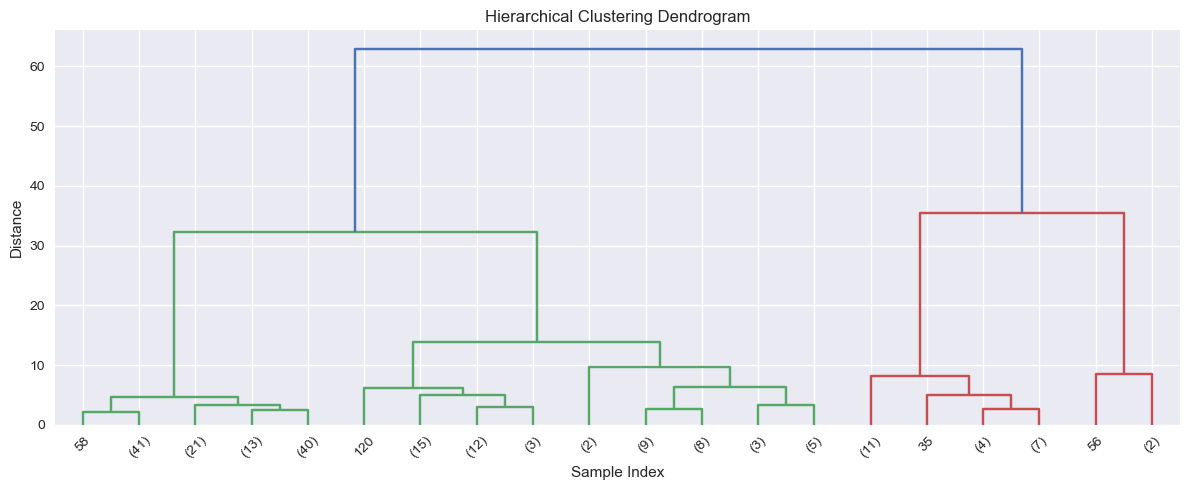

In [6]:
# Use a small sample for dendrogram
sample_idx = np.random.choice(len(X_pca), 200, replace=False)
X_sample = X_pca[sample_idx]

linked = linkage(X_sample, method='ward')

plt.figure(figsize=(12, 5))
dendrogram(linked, truncate_mode='lastp', p=20, leaf_rotation=45, leaf_font_size=10)
plt.title('Hierarchical Clustering Dendrogram')
plt.xlabel('Sample Index')
plt.ylabel('Distance')
plt.tight_layout()
plt.show()

## 5. DBSCAN

DBSCAN — Clusters: 4 | Noise points: 39


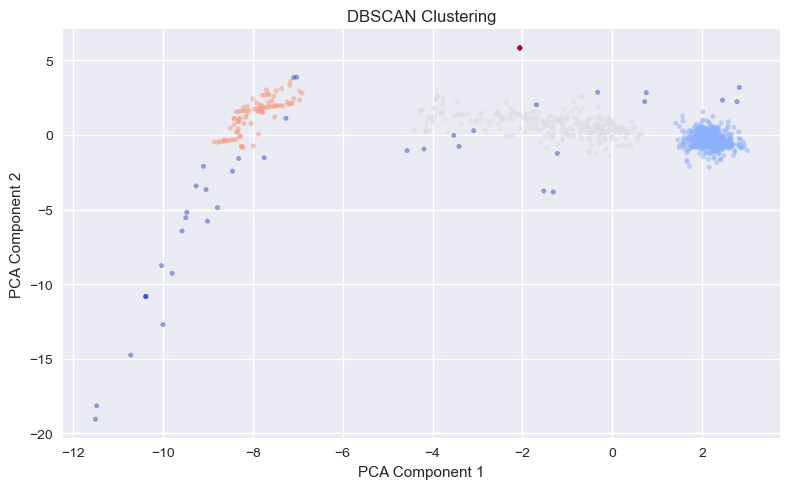

In [7]:
dbscan = DBSCAN(eps=0.5, min_samples=5)
dbscan_labels = dbscan.fit_predict(X_pca)

n_clusters = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)
n_noise = (dbscan_labels == -1).sum()
print(f"DBSCAN — Clusters: {n_clusters} | Noise points: {n_noise}")

plt.figure(figsize=(8, 5))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=dbscan_labels, cmap='coolwarm', alpha=0.5, s=10)
plt.title('DBSCAN Clustering')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.tight_layout()
plt.show()

## 6. Conclusion

In this notebook, we applied three clustering algorithms to credit card transaction data.

Key takeaways:
- **K-Means** is fast and simple but assumes spherical clusters and requires K to be specified upfront.
- The **Elbow Method** helps identify the optimal number of clusters.
- **Hierarchical Clustering** reveals nested structure and doesn't require K upfront.
- **DBSCAN** naturally identifies outliers as noise, making it well-suited for fraud detection where anomalies are sparse and irregularly shaped.